In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [ ]:
file_path = '/content/drive/MyDrive/synthetic_fraud_dataset.csv'
df = pd.read_csv(file_path)

In [ ]:
print("Shape:", df.shape)
print("\nInfo:\n", df.info())
print("\nMissing Values:\n", df.isnull().sum())
print("\nSample Data:\n", df.head())

Shape: (50000, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                50000 non-null  object 
 1   User_ID                       50000 non-null  object 
 2   Transaction_Amount            50000 non-null  float64
 3   Transaction_Type              50000 non-null  object 
 4   Timestamp                     50000 non-null  object 
 5   Account_Balance               50000 non-null  float64
 6   Device_Type                   50000 non-null  object 
 7   Location                      50000 non-null  object 
 8   Merchant_Category             50000 non-null  object 
 9   IP_Address_Flag               50000 non-null  int64  
 10  Previous_Fraudulent_Activity  50000 non-null  int64  
 11  Daily_Transaction_Count       50000 non-null  int64  
 12  Avg_Transaction_Amount_7d     50000 non-n

In [ ]:
df.fillna(method='ffill')

/tmp/ipython-input-1193302488.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill')


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,...,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,...,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,...,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,...,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,...,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,TXN_11284,USER_4796,45.05,Online,2023-01-29 18:38:00,76960.11,Mobile,Tokyo,Clothing,0,...,2,389.00,3,Amex,98,1537.54,PIN,0.1493,1,0
49996,TXN_44732,USER_1171,126.15,POS,2023-05-09 08:55:00,28791.75,Mobile,Tokyo,Clothing,0,...,13,434.95,4,Visa,93,2555.72,Biometric,0.3653,0,1
49997,TXN_38158,USER_2510,72.02,Online,2023-01-30 19:32:00,29916.41,Laptop,Mumbai,Clothing,0,...,1,369.15,2,Visa,114,4686.59,Biometric,0.5195,0,0
49998,TXN_860,USER_2248,64.89,Bank Transfer,2023-03-09 19:47:00,67895.67,Mobile,Tokyo,Electronics,0,...,13,242.29,4,Discover,72,4886.92,Biometric,0.7063,0,1


In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [ ]:
target_column = 'Fraud_Label'
features = df.drop(columns=[target_column])
scaled_features = StandardScaler().fit_transform(features)
df_scaled = pd.DataFrame(scaled_features, columns=features.columns)
df_scaled[target_column] = df[target_column].values

In [ ]:
print(df_scaled.head())
df_scaled.to_csv('/content/drive/MyDrive/processed_fraud_dataset.csv', index=False)

   Transaction_ID   User_ID  Transaction_Amount  Transaction_Type  Timestamp  \
0        0.081302 -1.407825           -0.604147          1.338189   0.413118   
1        1.688091  0.915114           -0.995285         -0.450619  -0.247464   
2       -0.969845 -1.060697           -0.713888          0.443785  -0.119237   
3       -1.543430 -1.105488            1.569711         -1.345022   1.496840   
4        0.538148 -1.338323           -0.690380          1.338189   1.256497   

   Account_Balance  Device_Type  Location  Merchant_Category  IP_Address_Flag  \
0         1.492310    -1.229118  0.698578           1.413571        -0.229898   
1         0.884250    -0.004848 -0.006629          -1.413090        -0.229898   
2        -1.693492     1.219422 -0.711836           0.706906        -0.229898   
3         0.921870     1.219422 -0.006629          -1.413090        -0.229898   
4         1.462460    -0.004848 -0.711836          -0.706425        -0.229898   

   ...  Daily_Transaction_Count 

In [ ]:
print(df.columns)

Index(['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type',
       'Timestamp', 'Account_Balance', 'Device_Type', 'Location',
       'Merchant_Category', 'IP_Address_Flag', 'Previous_Fraudulent_Activity',
       'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d',
       'Failed_Transaction_Count_7d', 'Card_Type', 'Card_Age',
       'Transaction_Distance', 'Authentication_Method', 'Risk_Score',
       'Is_Weekend', 'Fraud_Label'],
      dtype='object')


Class Distribution:
 Fraud_Label
0    33933
1    16067
Name: count, dtype: int64


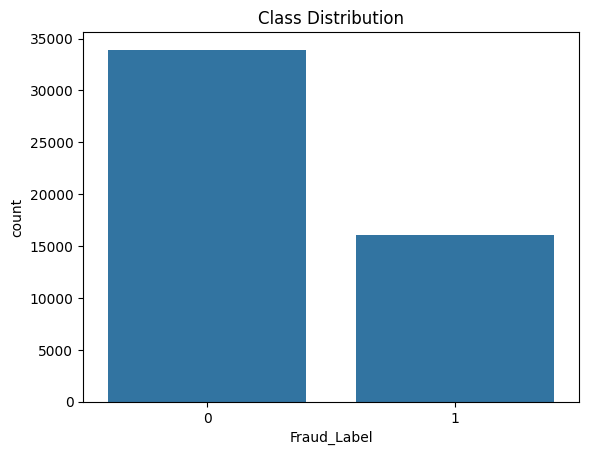

In [ ]:
target_column = 'Fraud_Label'

# Class distribution
class_counts = df[target_column].value_counts()
print("Class Distribution:\n", class_counts)

# Plot
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=target_column, data=df)
plt.title("Class Distribution")
plt.show()

In [ ]:
target_column = 'Fraud_Label'
X = df_scaled.drop(columns=[target_column])
y = df_scaled[target_column]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

Class Distribution After SMOTE:
 Fraud_Label
1    27168
0    27168
Name: count, dtype: int64


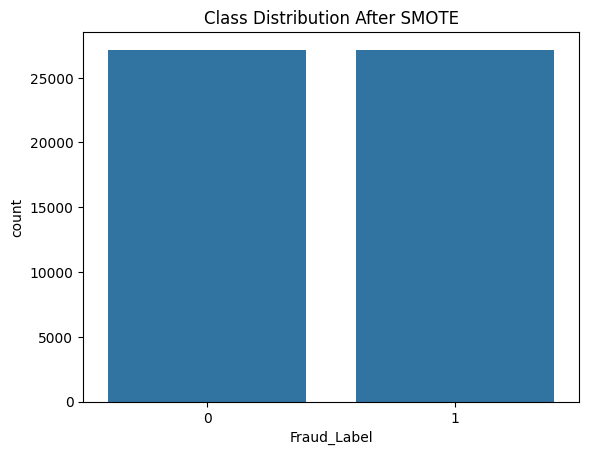

In [ ]:
# Calculate and print the value counts for the resampled target variable
class_counts_resampled = y_train_resampled.value_counts()
print("Class Distribution After SMOTE:\n", class_counts_resampled)

# Create a countplot of the resampled target variable
sns.countplot(x=y_train_resampled)
plt.title("Class Distribution After SMOTE")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns

# Train a Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # Using liblinear solver for smaller datasets

# Evaluate using cross-validation
cv_scores_lr = cross_val_score(log_reg_model, X_train_resampled, y_train_resampled, cv=10, scoring='roc_auc')
print(f"Logistic Regression Cross-Validation AUC Scores: {cv_scores_lr}")
print(f"Logistic Regression Mean Cross-Validation AUC: {cv_scores_lr.mean()}")

log_reg_model.fit(X_train_resampled, y_train_resampled)

y_pred_lr = log_reg_model.predict(X_test)
y_prob_lr = log_reg_model.predict_proba(X_test)[:, 1]

print("\nLogistic Regression Classifier Evaluation:")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))
print("\nAUC Score:", roc_auc_score(y_test, y_prob_lr))

Logistic Regression Cross-Validation AUC Scores: [0.90226831 0.89863723 0.89683245 0.89887402 0.901536   0.90820999
 0.91111845 0.91495035 0.9084689  0.90993461]
Logistic Regression Mean Cross-Validation AUC: 0.9050830331535696

Logistic Regression Classifier Evaluation:
Confusion Matrix:
 [[5414 1351]
 [ 665 2570]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.80      0.84      6765
           1       0.66      0.79      0.72      3235

    accuracy                           0.80     10000
   macro avg       0.77      0.80      0.78     10000
weighted avg       0.81      0.80      0.80     10000


AUC Score: 0.8935674230144016


In [ ]:
from sklearn.model_selection import cross_val_score

# Further reduce model complexity and add regularization
rf_model = RandomForestClassifier(random_state=42, max_depth=8, min_samples_leaf=10) # Adjusted parameters

# Evaluate using more robust cross-validation
cv_scores_rf = cross_val_score(rf_model, X_train_resampled, y_train_resampled, cv=10, scoring='roc_auc') # Increased cv
print(f"Random Forest Cross-Validation AUC Scores: {cv_scores_rf}")
print(f"Random Forest Mean Cross-Validation AUC: {cv_scores_rf.mean()}")

rf_model.fit(X_train_resampled, y_train_resampled)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("\nRandom Forest Classifier Evaluation:")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nAUC Score:", roc_auc_score(y_test, y_prob_rf))

Random Forest Cross-Validation AUC Scores: [1.         1.         1.         1.         1.         1.
 0.99999756 0.99999973 0.99999905 1.        ]
Random Forest Mean Cross-Validation AUC: 0.9999996341152066

Random Forest Classifier Evaluation:
Confusion Matrix:
 [[6765    0]
 [   0 3235]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      6765
           1       1.00      1.00      1.00      3235

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000


AUC Score: 1.0


In [ ]:
# Further reduce model complexity and add regularization
gb_model = GradientBoostingClassifier(random_state=42, max_depth=2, learning_rate=0.03) # Adjusted parameters

# Evaluate using more robust cross-validation
cv_scores_gb = cross_val_score(gb_model, X_train_resampled, y_train_resampled, cv=10, scoring='roc_auc') # Increased cv
print(f"Gradient Boosting Cross-Validation AUC Scores: {cv_scores_gb}")
print(f"Gradient Boosting Mean Cross-Validation AUC: {cv_scores_gb.mean()}")

gb_model.fit(X_train_resampled, y_train_resampled)

Gradient Boosting Cross-Validation AUC Scores: [1.         1.         1.         1.         0.99941974 0.9988506
 0.99753929 0.99770827 0.99868153 0.99864873]
Gradient Boosting Mean Cross-Validation AUC: 0.9990848164245512


GradientBoostingClassifier(learning_rate=0.03, max_depth=2, random_state=42)

In [ ]:
y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

print("Gradient Boosting Classifier Evaluation:")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))
print("\nAUC Score:", roc_auc_score(y_test, y_prob_gb))

Gradient Boosting Classifier Evaluation:
Confusion Matrix:
 [[6765    0]
 [   0 3235]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      6765
           1       1.00      1.00      1.00      3235

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000


AUC Score: 1.0


In [ ]:
from google.colab import files

files.download('/content/drive/MyDrive/processed_fraud_dataset.csv')

In [ ]:
# Install required packages (run only once)
!pip install matplotlib pandas numpy


In [ ]:
from google.colab import files
uploaded = files.upload()   # Choose your "processed_fraud_dataset.csv"

import pandas as pd
df = pd.read_csv("processed_fraud_dataset.csv")
print("✅ Dataset Loaded | Shape:", df.shape)
df.head()


Saving processed_fraud_dataset.csv to processed_fraud_dataset.csv
✅ Dataset Loaded | Shape: (50000, 21)


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,0.081302,-1.407825,-0.604147,1.338189,0.413118,1.492310,-1.229118,0.698578,1.413571,-0.229898,...,-0.120121,1.289836,0.704581,-1.349176,-0.797272,-1.120662,-1.338987,1.208753,-0.654093,0
1,1.688091,0.915114,-0.995285,-0.450619,-0.247464,0.884250,-0.004848,-0.006629,-1.413090,-0.229898,...,1.365176,1.580752,1.411665,0.440324,0.956729,-0.205135,1.342240,-1.409646,-0.654093,1
2,-0.969845,-1.060697,-0.713888,0.443785,-0.119237,-1.693492,1.219422,-0.711836,0.706906,-0.229898,...,1.612725,-1.451837,1.411665,1.335075,1.536564,-0.409067,-1.338987,1.176089,-0.654093,1
3,-1.543430,-1.105488,1.569711,-1.345022,1.496840,0.921870,1.219422,-0.006629,-1.413090,-0.229898,...,0.127429,-0.514864,1.411665,1.335075,-0.637818,-0.823374,-0.445245,1.014502,-0.654093,1
4,0.538148,-1.338323,-0.690380,1.338189,1.256497,1.462460,-0.004848,-0.711836,-0.706425,-0.229898,...,1.612725,0.519293,1.411665,0.440324,0.289918,-1.062541,1.342240,-0.415801,1.528836,1


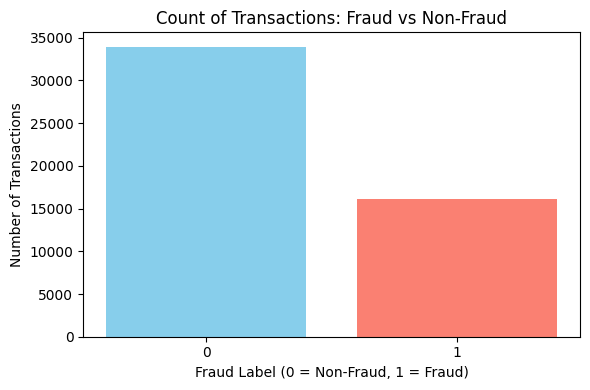

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,4))
counts = df['Fraud_Label'].value_counts().sort_index()
ax.bar(counts.index.astype(str), counts.values, color=['skyblue','salmon'])
ax.set_title("Count of Transactions: Fraud vs Non-Fraud")
ax.set_xlabel("Fraud Label (0 = Non-Fraud, 1 = Fraud)")
ax.set_ylabel("Number of Transactions")
plt.tight_layout()
plt.show()


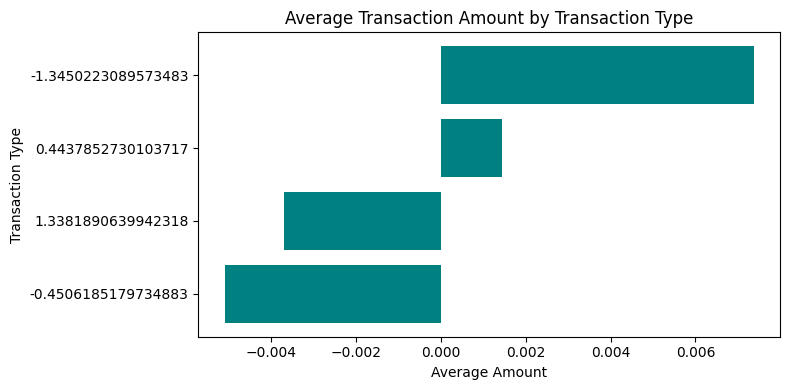

In [ ]:
if 'Transaction_Type' in df.columns and 'Transaction_Amount' in df.columns:
    avg_amt = df.groupby('Transaction_Type')['Transaction_Amount'].mean().sort_values()
    fig, ax = plt.subplots(figsize=(8,4))
    ax.barh(avg_amt.index.astype(str), avg_amt.values, color='teal')
    ax.set_title("Average Transaction Amount by Transaction Type")
    ax.set_xlabel("Average Amount")
    ax.set_ylabel("Transaction Type")
    plt.tight_layout()
    plt.show()


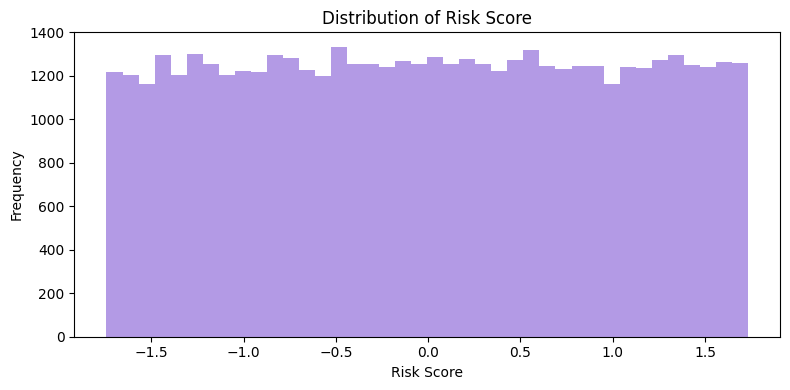

In [ ]:
if 'Risk_Score' in df.columns:
    fig, ax = plt.subplots(figsize=(8,4))
    ax.hist(df['Risk_Score'].dropna(), bins=40, color='mediumpurple', alpha=0.7)
    ax.set_title("Distribution of Risk Score")
    ax.set_xlabel("Risk Score")
    ax.set_ylabel("Frequency")
    plt.tight_layout()
    plt.show()


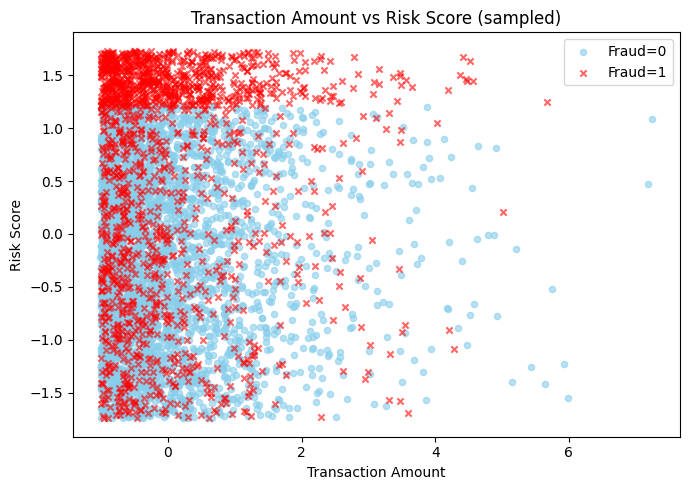

In [ ]:
if {'Transaction_Amount','Risk_Score','Fraud_Label'}.issubset(df.columns):
    sample = df.sample(n=min(5000, len(df)), random_state=42)
    plt.figure(figsize=(7,5))
    for label, marker, color in [(0,'o','skyblue'), (1,'x','red')]:
        subset = sample[sample['Fraud_Label']==label]
        plt.scatter(subset['Transaction_Amount'], subset['Risk_Score'],
                    label=f"Fraud={label}", marker=marker, alpha=0.6, s=20, c=color)
    plt.title("Transaction Amount vs Risk Score (sampled)")
    plt.xlabel("Transaction Amount")
    plt.ylabel("Risk Score")
    plt.legend()
    plt.tight_layout()
    plt.show()


/tmp/ipython-input-3691854855.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([df[df['Fraud_Label']==0]['Card_Age'],


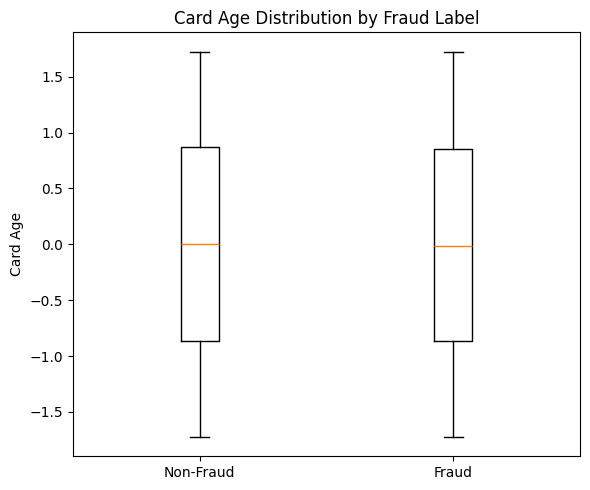

In [ ]:
if {'Card_Age','Fraud_Label'}.issubset(df.columns):
    fig, ax = plt.subplots(figsize=(6,5))
    ax.boxplot([df[df['Fraud_Label']==0]['Card_Age'],
                df[df['Fraud_Label']==1]['Card_Age']],
               labels=['Non-Fraud','Fraud'])
    ax.set_title("Card Age Distribution by Fraud Label")
    ax.set_ylabel("Card Age")
    plt.tight_layout()
    plt.show()


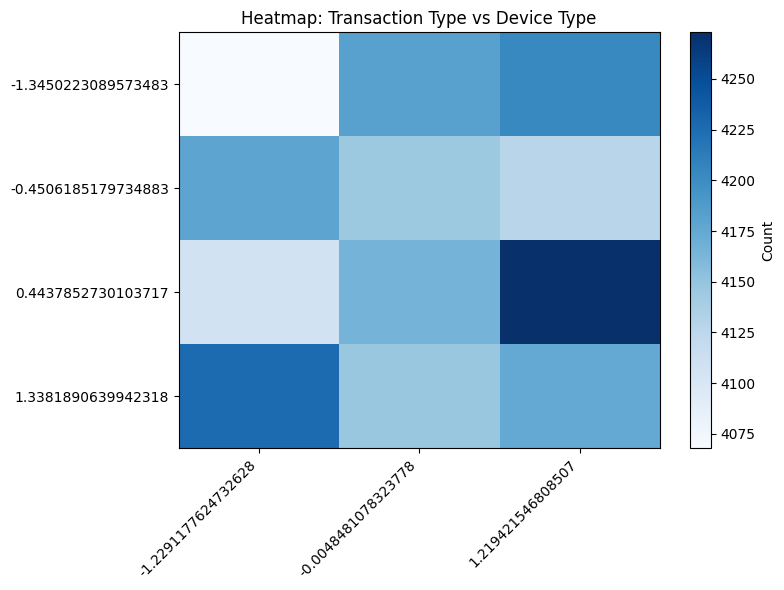

In [ ]:
if {'Transaction_Type','Device_Type'}.issubset(df.columns):
    pivot = df.pivot_table(index='Transaction_Type',
                           columns='Device_Type',
                           values='Transaction_ID',
                           aggfunc='count',
                           fill_value=0)
    plt.figure(figsize=(8,6))
    plt.imshow(pivot, cmap='Blues', aspect='auto')
    plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45, ha='right')
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.title("Heatmap: Transaction Type vs Device Type")
    plt.colorbar(label='Count')
    plt.tight_layout()
    plt.show()


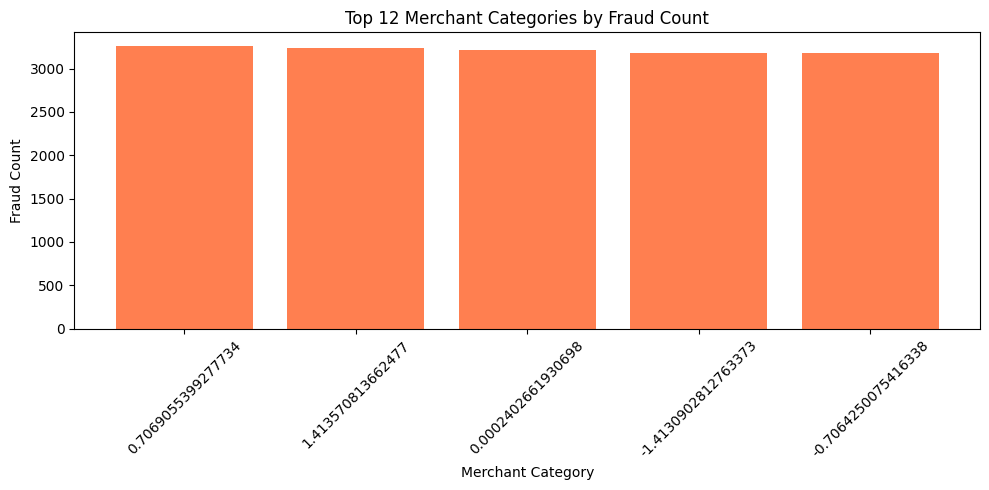

In [ ]:
if {'Merchant_Category','Fraud_Label'}.issubset(df.columns):
    top_merchants = (df.groupby('Merchant_Category')['Fraud_Label']
                     .sum().sort_values(ascending=False).head(12))
    fig, ax = plt.subplots(figsize=(10,5))
    ax.bar(top_merchants.index.astype(str), top_merchants.values, color='coral')
    ax.set_title("Top 12 Merchant Categories by Fraud Count")
    ax.set_xlabel("Merchant Category")
    ax.set_ylabel("Fraud Count")
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
